In [1]:
import tools

In [2]:
import time

In [3]:
tools.ext.np.set_printoptions(precision=8, suppress=True, floatmode="fixed")

In [4]:
fn1 = "../../../sub-1/ses-1/anat/sub-1_ses-1_T2w.nii.gz"
vol1 = tools.ext.nib.load(fn1)

In [5]:
A1 = vol1.get_fdata()

In [6]:
aff1 = vol1.affine

In [7]:
A1.shape

(128, 128, 128)

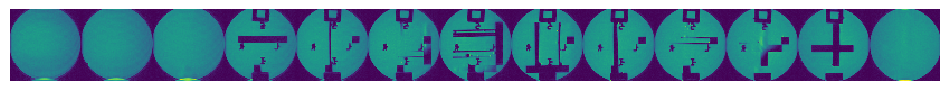

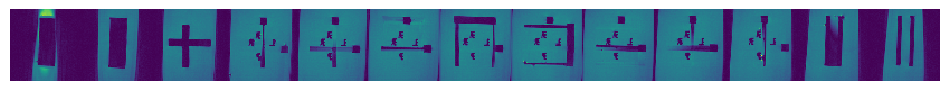

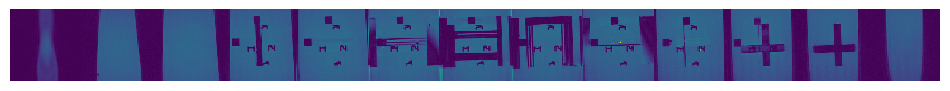

In [8]:
for mode in ["axial", "coronal", "sagittal"]: 
    tools.plot_slices(A1, mode, 10, decimate=2); 

(128, 128, 128)


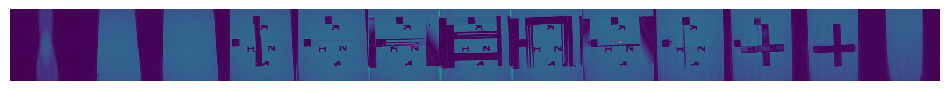

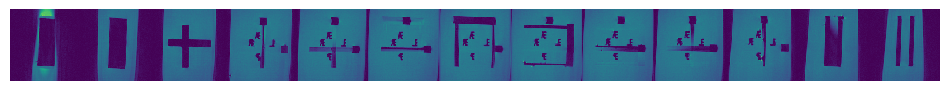

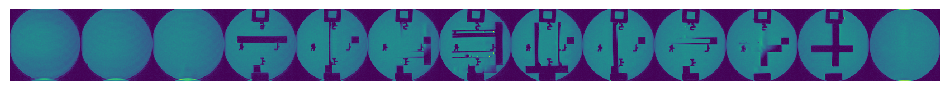

In [9]:
A1r = A1[:, :, :]
print(A1r.shape)
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A1r, mode, 10, decimate=1); 

In [10]:
print(aff1)

[[ -0.39062500   0.00000000   0.00000000  23.00000000]
 [  0.00000000   0.00000000   0.39100000 -27.82850075]
 [  0.00000000   0.39062500   0.00000000 -24.00000000]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]


In [11]:
tools.ext.np.sum(aff1 ** 2, 0) ** 0.5

array([ 0.39062500,  0.39062500,  0.39100000, 43.36387268])

In [12]:
t1 = time.time()
(A2, aff2) = tools.compute_subresolution_A1_aligned(
    # A1, (0.391, 0.391, 0.391), (2.5, 2.5, 2.5), nrand=1000)
    A1r, (0.391, 0.391, 0.391), (1.25, 1.25, 1.25), nrand=1000)
t2 = time.time()
print(t2 - t1)

104.84866046905518


In [13]:
A2.shape

(41, 41, 41)

In [14]:
(A0, aff0) = tools.load_template("../templates/template-phantom-mri_resolution-1250.nii.gz")

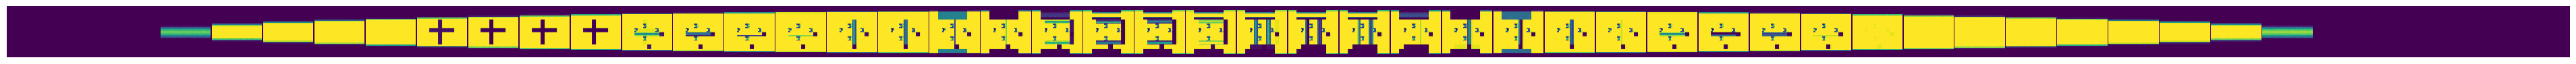

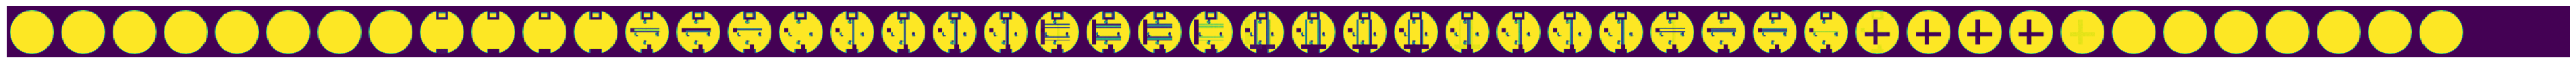

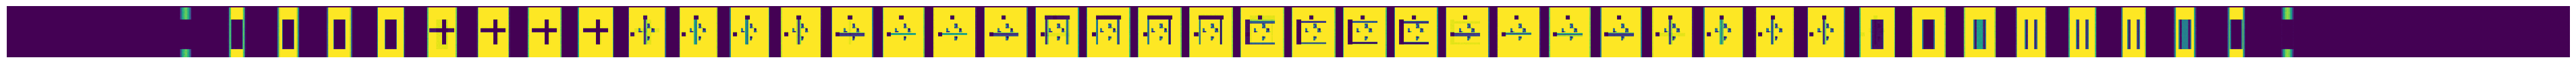

In [15]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0, mode); 

In [16]:
A0.shape

(49, 49, 49)

In [17]:
A0r = A0[9:-9, 9:-9, 9:-9]
print(A0r.shape)
patterns = tools.compute_patterns(A0r)

(31, 31, 31)


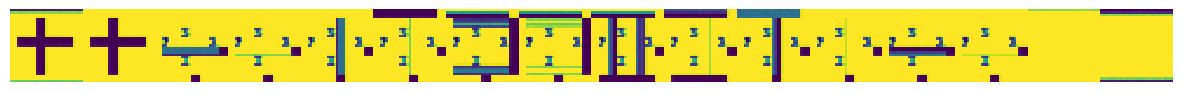

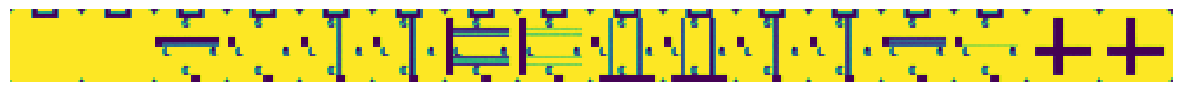

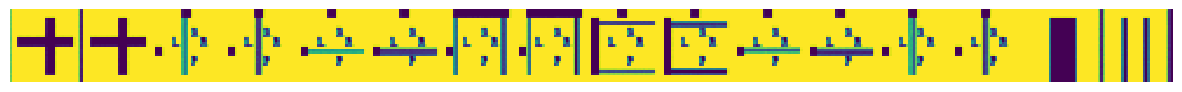

In [18]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0r, mode, step=2); 

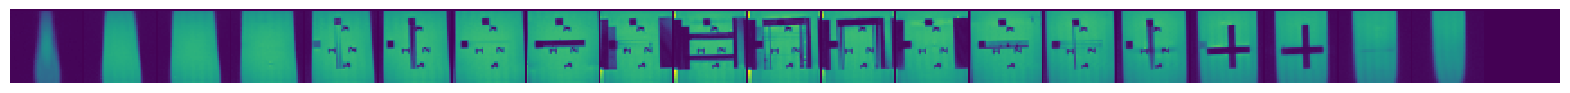

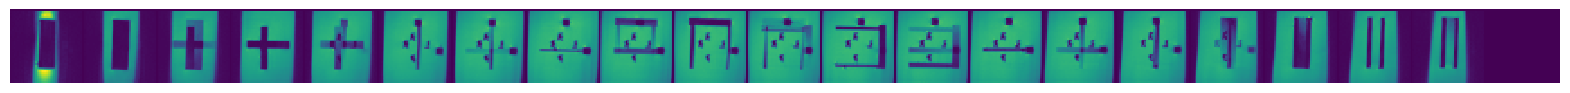

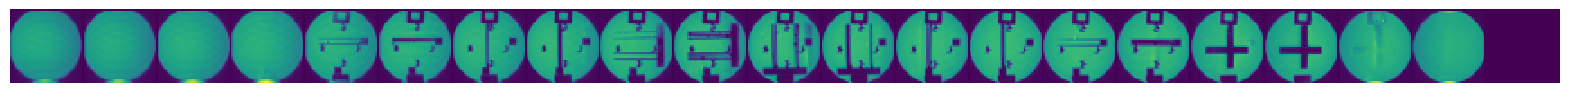

In [19]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A2, mode, decimate=1, step=2); 

In [21]:
res = {}
t1 = time.time()
for k in patterns: 
    Ak = patterns[k]
    ck = tools.compute_A_inside_B_best_translation(Ak, A2)
    res[k] = {"i": ck[0], "j": ck[1], "k": ck[2], "c": ck[3]}
t2 = time.time()
print(t2 - t1)
df1 = tools.ext.pd.DataFrame(res)
df2 = df1.T
df3 = df2.sort_values(by="c")

5.349954843521118


In [22]:
df3

,i,j,k,c
"False_True_True_(1, 0, 2)",3.0,5.0,0.0,0.875268
"False_False_False_(0, 1, 2)",5.0,6.0,0.0,0.877542
"False_True_False_(1, 0, 2)",3.0,6.0,2.0,0.878102
"True_True_False_(1, 0, 2)",4.0,5.0,1.0,0.878617
"True_True_True_(1, 0, 2)",6.0,5.0,4.0,0.881250
"False_True_False_(0, 1, 2)",6.0,5.0,7.0,0.881502
"False_False_True_(0, 1, 2)",5.0,6.0,0.0,0.884430
"False_True_True_(0, 1, 2)",5.0,5.0,3.0,0.887414
"False_True_False_(1, 2, 0)",6.0,6.0,4.0,0.891072
"True_False_False_(0, 1, 2)",4.0,6.0,1.0,0.891277


In [23]:
print(aff1)

[[ -0.39062500   0.00000000   0.00000000  23.00000000]
 [  0.00000000   0.00000000   0.39100000 -27.82850075]
 [  0.00000000   0.39062500   0.00000000 -24.00000000]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]


In [24]:
(flips1, orientations1) = tools.compute_flips_permutations(aff1)
print(flips1, orientations1)

[True, False, False] [np.int64(0), np.int64(2), np.int64(1)]


In [25]:
(flips2, orientations2) = ([True, False, False], [0, 2, 1])

In [26]:
tools.test_flips_orientations(flips1, flips2, orientations1, orientations2)

'......'

In [27]:
aff1r = tools.compute_transformed_affine(aff1, flips2, orientations2) 

In [28]:
print(aff1r)

[[ -0.39062500   0.00000000   0.00000000  23.00000000]
 [  0.00000000   0.00000000   0.39100000 -27.82850075]
 [  0.00000000   0.39062500   0.00000000 -24.00000000]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]
